# **Análisis estadístico y depuración del código**

In [23]:
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
import numpy as np

In [24]:
da_SGC_50 = pd.read_csv('../datos/datos originales/SGC-50KM.csv')
da_SGC_260 = pd.read_csv('../datos/datos originales/SGC-260KM.csv')
da_USGS_50 = pd.read_csv('../datos/datos originales/USGS-50KM.csv')
da_USGC_260 = pd.read_csv('../datos/datos originales/USGS-260KM.csv')

# **Homogenización de los nombre de las columnas y formato de hora**

In [30]:
import pandas as pd
import os

# 1. Rutas de los archivos SGC
archivos_sgc = [
    r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGC-50KM.csv",
    r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGC-260KM.csv"
]

# 2. Diccionario para renombrar columnas del SGC
columnas_map_sgc = {
    'agency': 'agencia',
    'place': 'lugar',
    'local_time': 'hora',
    'latitude': 'latitud',
    'longitude': 'longitud',
    'magnitude': 'magnitud',
    'mag_type': 'tipo_magnitud',
    'depth': 'profundidad'
}

orden_columnas = [
    'agencia', 'lugar', 'hora', 'latitud', 'longitud', 
    'magnitud', 'tipo_magnitud', 'profundidad'
]

dataframes_procesados = []

# Procesar cada archivo del SGC
for archivo in archivos_sgc:
    try:
        df = pd.read_csv(archivo)
        
        # Evitar columnas duplicadas
        df = df.loc[:, ~df.columns.duplicated()]
        
        # Renombrar y filtrar
        df.rename(columns=columnas_map_sgc, inplace=True)
        columnas_finales = [col for col in orden_columnas if col in df.columns]
        df_transformado = df[columnas_finales]
        
        # Guardar archivo con sufijo _n
        ruta_base, extension = os.path.splitext(archivo)
        nuevo_archivo = f"{ruta_base}_n{extension}"
        df_transformado.to_csv(nuevo_archivo, index=False)
        print(f"[ÉXITO] Archivo transformado y guardado: {os.path.basename(nuevo_archivo)}")
        
        # Guardar en la lista para el análisis global
        dataframes_procesados.append(df_transformado)

    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo: {archivo}. Verifica la ruta.")
    except Exception as e:
        print(f"[ERROR] Ocurrió un problema con {os.path.basename(archivo)}: {e}")

# --- ANÁLISIS ESTADÍSTICO CONJUNTO ---
if len(dataframes_procesados) > 0:
    print("\n" + "="*70)
    print("ANÁLISIS ESTADÍSTICO GLOBAL (SGC 50KM + 260KM COMBINADOS)")
    print("="*70)
    
    # Unir todos los DataFrames cargados exitosamente
    df_total = pd.concat(dataframes_procesados, ignore_index=True)
    
    print("\n--- REVISIÓN DE VALORES NULOS (TOTAL) ---")
    print(df_total.isnull().sum())
    
    print("\n--- ESTADÍSTICA DESCRIPTIVA BÁSICA (TOTAL) ---")
    print(df_total.describe(include='all'))
else:
    print("\nNo se pudieron cargar los archivos para el análisis.")

[ÉXITO] Archivo transformado y guardado: SGC-50KM_n.csv
[ÉXITO] Archivo transformado y guardado: SGC-260KM_n.csv

ANÁLISIS ESTADÍSTICO GLOBAL (SGC 50KM + 260KM COMBINADOS)

--- REVISIÓN DE VALORES NULOS (TOTAL) ---
agencia          0
lugar            0
hora             0
latitud          0
longitud         0
magnitud         0
tipo_magnitud    0
profundidad      0
dtype: int64

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (TOTAL) ---
       agencia                     lugar                       hora  \
count    70161                     70161                      70161   
unique       4                       457                      67756   
top        SGC  Mesetas - Meta, Colombia  2026-06-10T19:45:56+00:00   
freq     70144                      5221                          4   
mean       NaN                       NaN                        NaN   
std        NaN                       NaN                        NaN   
min        NaN                       NaN                        NaN   
25% 

In [31]:
import pandas as pd
import os

# 1. Rutas de los archivos USGS
archivos_usgs = [
    r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\USGS-50KM.csv",
    r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\USGS-260KM.csv"
]

# 2. Diccionario para renombrar columnas del USGS
columnas_map_usgs = {
    'net': 'agencia',
    'place': 'lugar',
    'time': 'hora',
    'latitude': 'latitud',
    'longitude': 'longitud',
    'mag': 'magnitud',
    'magType': 'tipo_magnitud',
    'depth': 'profundidad'
}

orden_columnas = [
    'agencia', 'lugar', 'hora', 'latitud', 'longitud', 
    'magnitud', 'tipo_magnitud', 'profundidad'
]

dataframes_procesados = []

# Procesar cada archivo del USGS
for archivo in archivos_usgs:
    try:
        df = pd.read_csv(archivo)
        
        # Evitar columnas duplicadas
        df = df.loc[:, ~df.columns.duplicated()]
        
        # Renombrar columnas
        df.rename(columns=columnas_map_usgs, inplace=True)
        
        # ---------------------------------------------------------------------
        # HOMOGENEIZACIÓN Y ESTANDARIZACIÓN DE FECHA/HORA
        # ---------------------------------------------------------------------
        if 'hora' in df.columns:
            # Convierte cadenas ISO 8601 (con T y Z) a Timestamp UTC estandarizado
            df['hora'] = pd.to_datetime(df['hora'], errors='coerce', utc=True)
            
            # (Opcional) Si prefieres separar fecha y hora en columnas independientes:
            # df['fecha'] = df['hora'].dt.strftime('%Y-%m-%d')
            # df['hora_solo'] = df['hora'].dt.strftime('%H:%M:%S')

        # Filtrar al orden deseado
        columnas_finales = [col for col in orden_columnas if col in df.columns]
        df_transformado = df[columnas_finales].copy()
        
        # Guardar archivo con sufijo _n
        ruta_base, extension = os.path.splitext(archivo)
        nuevo_archivo = f"{ruta_base}_n{extension}"
        
        # Se guarda manteniendo el estándar ISO UTC reconocible por Pandas
        df_transformado.to_csv(nuevo_archivo, index=False, encoding="utf-8-sig")
        print(f"[ÉXITO] Archivo transformado y guardado: {os.path.basename(nuevo_archivo)}")
        
        # Guardar en la lista para el análisis global
        dataframes_procesados.append(df_transformado)

    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo: {archivo}. Verifica la ruta.")
    except Exception as e:
        print(f"[ERROR] Ocurrió un problema con {os.path.basename(archivo)}: {e}")

# --- ANÁLISIS ESTADÍSTICO CONJUNTO ---
if len(dataframes_procesados) > 0:
    print("\n" + "="*70)
    print("ANÁLISIS ESTADÍSTICO GLOBAL (USGS 50KM + 260KM COMBINADOS)")
    print("="*70)
    
    # Unir todos los DataFrames cargados exitosamente
    df_total = pd.concat(dataframes_procesados, ignore_index=True)
    
    print("\n--- REVISIÓN DE VALORES NULOS (TOTAL) ---")
    print(df_total.isnull().sum())
    
    print("\n--- ESTADÍSTICA DESCRIPTIVA BÁSICA (TOTAL) ---")
    print(df_total.describe(include='all'))
else:
    print("\nNo se pudieron cargar los archivos para el análisis.")

[ÉXITO] Archivo transformado y guardado: USGS-50KM_n.csv
[ÉXITO] Archivo transformado y guardado: USGS-260KM_n.csv

ANÁLISIS ESTADÍSTICO GLOBAL (USGS 50KM + 260KM COMBINADOS)

--- REVISIÓN DE VALORES NULOS (TOTAL) ---
agencia           0
lugar             0
hora              0
latitud           0
longitud          0
magnitud          0
tipo_magnitud    12
profundidad       0
dtype: int64

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (TOTAL) ---
       agencia     lugar                              hora     latitud  \
count      843       843                               843  843.000000   
unique       2       768                               NaN         NaN   
top         us  Colombia                               NaN         NaN   
freq       828        16                               NaN         NaN   
mean       NaN       NaN  1999-07-15 03:12:41.244405+00:00    3.916390   
min        NaN       NaN  1917-08-30 03:24:19.570000+00:00    1.170000   
25%        NaN       NaN  1991-01-22 15:44:


PROCESANDO UNIFICACIÓN: Radio 50 KM
Filas iniciales: 2400 | Filas tras eliminar nulos: 2400
[ÉXITO] Archivo depurado guardado en:
C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_50KM_Depurados.csv

--- ESTADÍSTICAS DE MAGNITUD (Radio 50 KM) ---
count    2400.000000
mean        1.842996
std         0.628043
min         0.700000
25%         1.400000
50%         1.700000
75%         2.100000
max         5.500000
Name: magnitud, dtype: float64

Abriendo ventana de gráficos para Radio 50 KM...


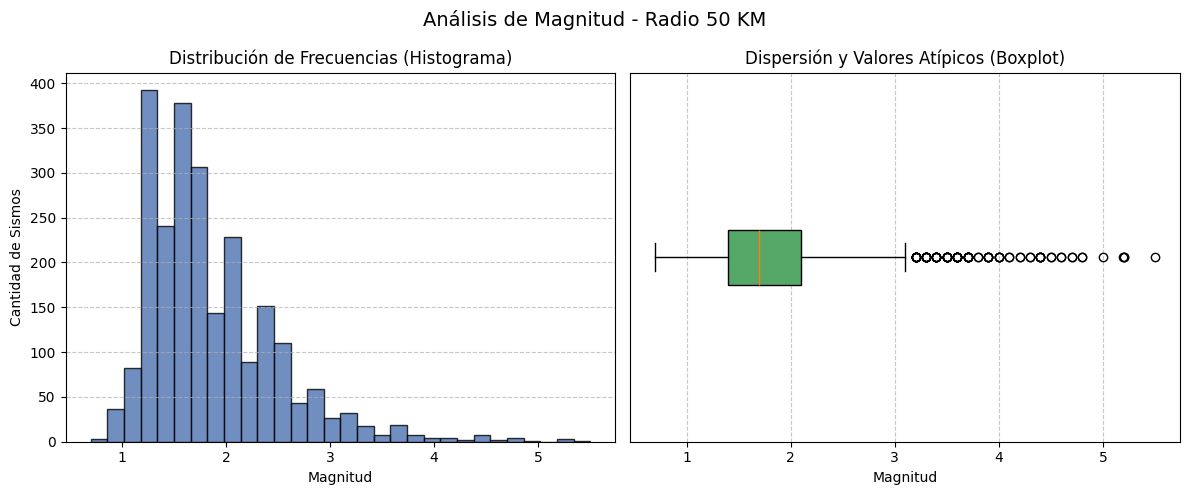


PROCESANDO UNIFICACIÓN: Radio 260 KM
Filas iniciales: 68604 | Filas tras eliminar nulos: 68592
[ÉXITO] Archivo depurado guardado en:
C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_260KM_Depurados.csv

--- ESTADÍSTICAS DE MAGNITUD (Radio 260 KM) ---
count    68592.000000
mean         1.701604
std          0.686206
min         -0.100000
25%          1.200000
50%          1.600000
75%          2.000000
max          7.400000
Name: magnitud, dtype: float64

Abriendo ventana de gráficos para Radio 260 KM...


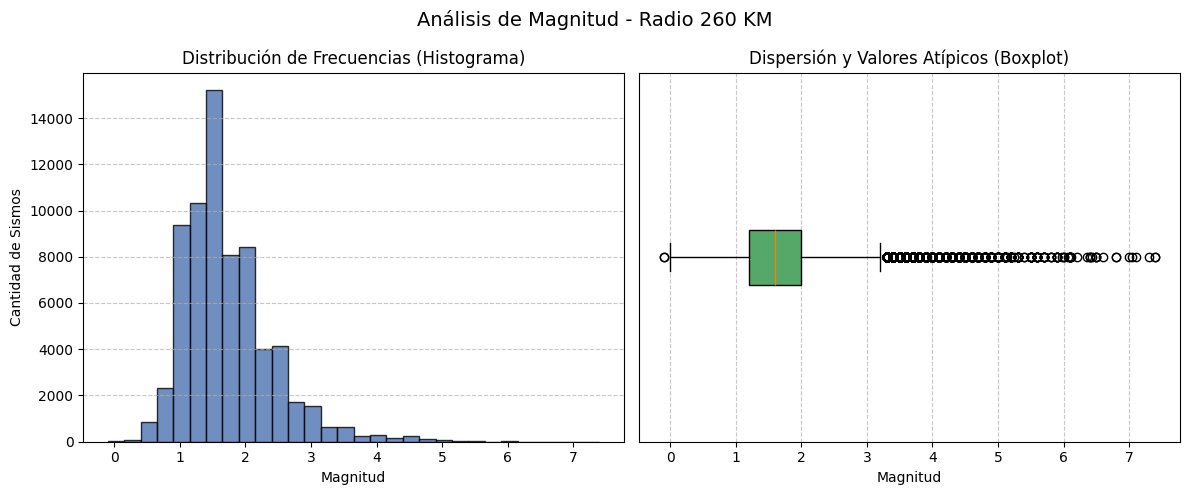

In [32]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. Definir rutas de entrada
ruta_sgc_50 = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGC-50KM_n.csv"
ruta_usgs_50 = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\USGS-50KM_n.csv"

ruta_sgc_260 = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGC-260KM_n.csv"
ruta_usgs_260 = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\USGS-260KM_n.csv"

# 2. Definir ruta de salida y asegurar que el directorio exista
ruta_salida_dir = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"
os.makedirs(ruta_salida_dir, exist_ok=True)

def procesar_unificacion_y_graficos(archivo_sgc, archivo_usgs, nombre_salida, titulo):
    print(f"\n" + "="*60)
    print(f"PROCESANDO UNIFICACIÓN: {titulo}")
    print("="*60)
    
    try:
        # Cargar ambos archivos transformados
        df_sgc = pd.read_csv(archivo_sgc)
        df_usgs = pd.read_csv(archivo_usgs)
        
        # Unificar (concatenar) los dos DataFrames
        df_unificado = pd.concat([df_sgc, df_usgs], ignore_index=True)
        total_inicial = len(df_unificado)
        
        # Eliminar filas con cualquier valor nulo
        df_unificado.dropna(inplace=True)
        total_final = len(df_unificado)
        print(f"Filas iniciales: {total_inicial} | Filas tras eliminar nulos: {total_final}")
        
        # Guardar en la nueva ruta
        ruta_final = os.path.join(ruta_salida_dir, nombre_salida)
        df_unificado.to_csv(ruta_final, index=False)
        print(f"[ÉXITO] Archivo depurado guardado en:\n{ruta_final}")
        
        # --- ESTADÍSTICA DESCRIPTIVA DE LA MAGNITUD ---
        print(f"\n--- ESTADÍSTICAS DE MAGNITUD ({titulo}) ---")
        print(df_unificado['magnitud'].describe())
        
        # --- GRAFICAR DISTRIBUCIÓN ---
        # Crear una figura con dos subgráficos (Histograma y Boxplot)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Análisis de Magnitud - {titulo}', fontsize=14)
        
        # Histograma
        axes[0].hist(df_unificado['magnitud'], bins=30, color='#4C72B0', edgecolor='black', alpha=0.8)
        axes[0].set_title('Distribución de Frecuencias (Histograma)')
        axes[0].set_xlabel('Magnitud')
        axes[0].set_ylabel('Cantidad de Sismos')
        axes[0].grid(axis='y', linestyle='--', alpha=0.7)
        
        # Boxplot (Diagrama de caja)
        axes[1].boxplot(df_unificado['magnitud'], vert=False, patch_artist=True, 
                        boxprops=dict(facecolor='#55A868', color='black'))
        axes[1].set_title('Dispersión y Valores Atípicos (Boxplot)')
        axes[1].set_xlabel('Magnitud')
        axes[1].set_yticks([]) # Ocultar el número 1 del eje Y
        axes[1].grid(axis='x', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        
        # Mostrar el gráfico en pantalla
        print(f"\nAbriendo ventana de gráficos para {titulo}...")
        plt.show()
        
    except FileNotFoundError as e:
        print(f"[ERROR] No se encontró uno de los archivos para {titulo}. Detalles: {e}")
    except Exception as e:
        print(f"[ERROR] Ocurrió un problema inesperado en {titulo}: {e}")

# 3. Ejecutar el proceso para la base de 50 KM
procesar_unificacion_y_graficos(
    ruta_sgc_50, 
    ruta_usgs_50, 
    "Sismos_50KM_Depurados.csv", 
    "Radio 50 KM"
)

# 4. Ejecutar el proceso para la base de 260 KM
procesar_unificacion_y_graficos(
    ruta_sgc_260, 
    ruta_usgs_260, 
    "Sismos_260KM_Depurados.csv", 
    "Radio 260 KM"
)


REPORTE PARA: Sismos_50KM_Depurados.csv
Filas iniciales en el archivo: 2400
Sismos conservados (Mw >= 3.0): 110
Total de registros eliminados (< 3.0, no convertidos o extrapolados): 2290
-> Archivo guardado en: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_50KM_Depurados_mw.csv

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw >= 3.0) ---
count    110.000000
mean       3.687833
std        0.624671
min        3.069800
25%        3.165600
50%        3.453000
75%        4.117587
max        5.500000
Name: escala_mw, dtype: float64

Abriendo ventana de gráficos para Sismos_50KM_Depurados...


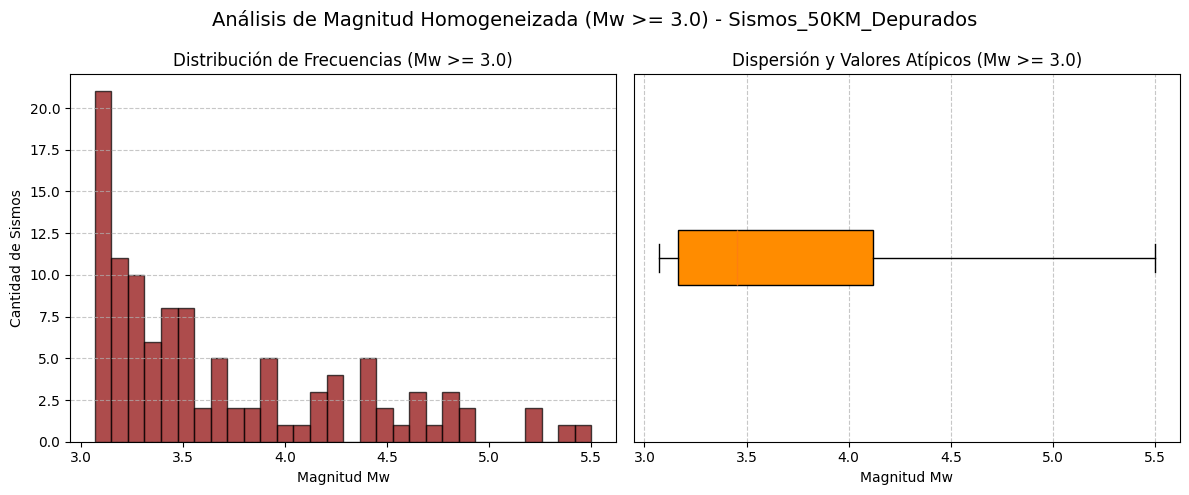


REPORTE PARA: Sismos_260KM_Depurados.csv
Filas iniciales en el archivo: 68592
Sismos conservados (Mw >= 3.0): 2874
Total de registros eliminados (< 3.0, no convertidos o extrapolados): 65718
-> Archivo guardado en: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\Sismos_260KM_Depurados_mw.csv

--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw >= 3.0) ---
count    2874.000000
mean        3.741755
std         0.690986
min         3.000000
25%         3.165600
50%         3.453000
75%         4.123600
max         7.400000
Name: escala_mw, dtype: float64

Abriendo ventana de gráficos para Sismos_260KM_Depurados...


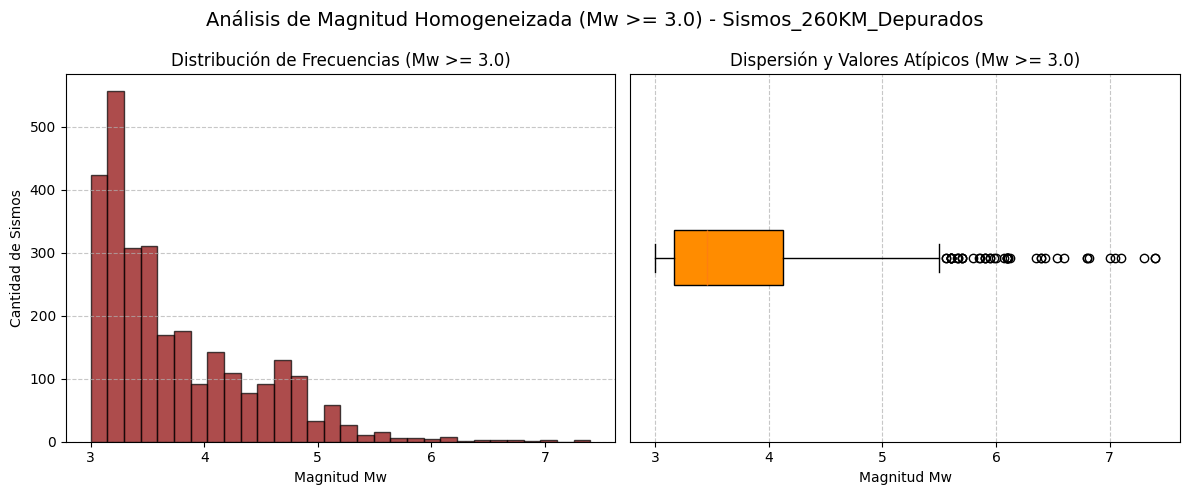

In [37]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Rutas de trabajo
DIRECTORIO_DEPURADOS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"

# Archivos de entrada
archivos_entrada = [
    "Sismos_50KM_Depurados.csv",
    "Sismos_260KM_Depurados.csv"
]

def convertir_a_mw(magnitud, tipo_magnitud):
    try:
        valor = float(magnitud)
    except (TypeError, ValueError):
        return (pd.NA, "sin magnitud", pd.NA, "sin_magnitud")

    tipo = "" if pd.isna(tipo_magnitud) else str(tipo_magnitud).strip().lower()
    tipo_base = tipo.replace("_", "").replace("-", "")

    # 1. Magnitudes reportadas directamente como Mw
    if tipo in {"mw", "mww", "mwc", "mwb", "mwr", "mwp"}:
        return (valor, "directa: " + str(tipo_magnitud), 0.0, "directa")
    if tipo in {"mw(mb)", "mwb(mb)"}:
        return (valor, "directa reportada: " + str(tipo_magnitud), 0.0, "directa")

    # 2. Conversión desde ondas de cuerpo (mb)
    if tipo in {"mb", "mbasic"} or tipo_base == "mb":
        if 3.6 < valor <= 5.7:
            mw = 0.954 * valor + 0.42
            return (mw, "Mw = 0.954 mb + 0.42", 0.28, "convertida")
        elif 5.7 < valor <= 7.7:
            mw = 1.433 * valor - 2.35
            return (mw, "Mw = 1.433 mb - 2.35", 0.36, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    # 3. Conversión desde ondas superficiales (Ms)
    if tipo in {"ms", "msk"}:
        if 3.6 < valor <= 6.1:
            mw = 0.689 * valor + 1.93
            return (mw, "Mw = 0.689 Ms + 1.93", 0.20, "convertida")
        elif 6.1 < valor <= 8.9:
            mw = 0.928 * valor + 0.474
            return (mw, "Mw = 0.928 Ms + 0.474", 0.18, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    # 4. Conversión desde magnitud local (ML)
    es_local = (tipo in {"ml", "mlr", "mlv"} or tipo.startswith("mlr") or "mlr" in tipo)
    if es_local:
        if 2.9 < valor <= 6.1:
            mw = 0.958 * valor + 0.1
            return (mw, "Mw = 0.958 ML + 0.1", 0.50, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    # 5. Conversión desde magnitud de duración (Md)
    if tipo in {"md", "mc"}:
        if 3.5 <= valor <= 7.4:
            mw = 0.7947 * valor + 1.3420
            return (mw, "Mw = 0.7947 Md + 1.3420", pd.NA, "convertida")
        else:
            return (pd.NA, "fuera_de_rango", pd.NA, "eliminada_extrapolacion")

    return (pd.NA, "sin correlacion verificable", pd.NA, "no_convertida")


def agregar_columnas_mw(df):
    conversiones = [
        convertir_a_mw(mag, tipo)
        for mag, tipo in zip(df["magnitud"], df["tipo_magnitud"])
    ]
    df[["escala_mw", "relacion_conversion", "sigma_conversion", "estado_conversion"]] = pd.DataFrame(conversiones, index=df.index)
    return df


for archivo in archivos_entrada:
    ruta_completa_entrada = os.path.join(DIRECTORIO_DEPURADOS, archivo)
    
    try:
        # Cargar el archivo previamente depurado
        df_depurado = pd.read_csv(ruta_completa_entrada)
        total_inicial = len(df_depurado)
        
        # Aplicar la conversión a Mw
        df_homogeneizado = agregar_columnas_mw(df_depurado)
        
        # 1. Eliminar filas no convertidas o extrapoladas (NaN en escala_mw)
        df_homogeneizado = df_homogeneizado.dropna(subset=['escala_mw']).copy()
        df_homogeneizado['escala_mw'] = df_homogeneizado['escala_mw'].astype(float)
        
        # 2. FILTRO: MANTENER ÚNICAMENTE SISMOS CON Mw >= 3.0
        df_homogeneizado = df_homogeneizado[df_homogeneizado['escala_mw'] >= 3.0].copy()
        
        total_final = len(df_homogeneizado)
        sismos_eliminados = total_inicial - total_final
        
        # Guardar archivo
        nombre_base, extension = os.path.splitext(archivo)
        archivo_salida = f"{nombre_base}_mw{extension}"
        ruta_completa_salida = os.path.join(DIRECTORIO_DEPURADOS, archivo_salida)
        df_homogeneizado.to_csv(ruta_completa_salida, index=False, encoding="utf-8-sig")
        
        # --- REPORTE EN CONSOLA ---
        print(f"\n" + "="*65)
        print(f"REPORTE PARA: {archivo}")
        print("="*65)
        print(f"Filas iniciales en el archivo: {total_inicial}")
        print(f"Sismos conservados (Mw >= 3.0): {total_final}")
        print(f"Total de registros eliminados (< 3.0, no convertidos o extrapolados): {sismos_eliminados}")
        print(f"-> Archivo guardado en: {ruta_completa_salida}")
        
        print("\n--- ESTADÍSTICA DESCRIPTIVA BÁSICA (ESCALA Mw >= 3.0) ---")
        print(df_homogeneizado['escala_mw'].describe())
        
        # --- GRÁFICOS SOBRE LOS SISMOS FILTRADOS ---
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Análisis de Magnitud Homogeneizada (Mw >= 3.0) - {nombre_base}', fontsize=14)
        
        # Histograma
        axes[0].hist(df_homogeneizado['escala_mw'], bins=30, color='#8B0000', edgecolor='black', alpha=0.7)
        axes[0].set_title('Distribución de Frecuencias (Mw >= 3.0)')
        axes[0].set_xlabel('Magnitud Mw')
        axes[0].set_ylabel('Cantidad de Sismos')
        axes[0].grid(axis='y', linestyle='--', alpha=0.7)
        
        # Diagrama de caja (Boxplot)
        axes[1].boxplot(df_homogeneizado['escala_mw'], vert=False, patch_artist=True, 
                        boxprops=dict(facecolor='#FF8C00', color='black'))
        axes[1].set_title('Dispersión y Valores Atípicos (Mw >= 3.0)')
        axes[1].set_xlabel('Magnitud Mw')
        axes[1].set_yticks([]) 
        axes[1].grid(axis='x', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        print(f"\nAbriendo ventana de gráficos para {nombre_base}...")
        plt.show()
        
    except FileNotFoundError:
        print(f"\n[ERROR] No se encontró el archivo: {ruta_completa_entrada}")
    except Exception as e:
        print(f"\n[ERROR] Ocurrió un problema con {archivo}: {e}")

In [38]:
import os
import numpy as np
import pandas as pd

# ----------------- CONFIGURACIÓN DE RUTAS -----------------
DIR_DATOS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"

# ARCHIVOS CONFIGURADOS CON NOMENCLATURA _onlymw
ARCHIVOS = {
    "Sismos_260KM_Depurados_mw.csv": "Sismos_260KM_Depurados_onlymw.csv",
    "Sismos_50KM_Depurados_mw.csv": "Sismos_50KM_Depurados_onlymw.csv"
}

def haversine_km(lat1, lon1, lat2, lon2):
    """Calcula distancia usando matemáticas de arreglos rápidos (Numpy)."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

def parsear_fechas_robustas(df):
    """Extrae la fecha y hora reconociendo formatos ISO 8601 (con T y Z) y mixtos."""
    dt_series = pd.Series(pd.NaT, index=df.index, dtype='datetime64[ns, UTC]')
    cols_lower = {c.lower(): c for c in df.columns}
    
    # 1. Evaluar columnas individuales por si traen timestamp ISO completo
    columnas_posibles = ["time", "fecha_hora", "datetime", "timestamp", "date", "fecha", "origintime", "hora"]
    
    for col_key in columnas_posibles:
        if col_key in cols_lower:
            real_col = cols_lower[col_key]
            s = df[real_col].astype(str).str.strip()
            
            try:
                parsed = pd.to_datetime(s, format="ISO8601", errors="coerce", utc=True)
            except Exception:
                parsed = pd.to_datetime(s, format="mixed", errors="coerce", utc=True)
                
            if parsed.isna().all():
                parsed = pd.to_datetime(s, format="mixed", errors="coerce", utc=True)
                
            dt_series = dt_series.fillna(parsed)
            
    # 2. Si quedan filas sin fecha y existen columnas 'fecha' y 'hora' separadas, combinarlas
    if dt_series.isna().any() and "fecha" in cols_lower and "hora" in cols_lower:
        mask_vacios = dt_series.isna()
        col_f = cols_lower["fecha"]
        col_h = cols_lower["hora"]
        
        f_vals = df.loc[mask_vacios, col_f].astype(str).str.strip().replace(["nan", "None", "NaN"], "")
        h_vals = df.loc[mask_vacios, col_h].astype(str).str.strip().replace(["nan", "None", "NaN"], "")
        
        str_combo = (f_vals + " " + h_vals).str.strip()
        parsed_combo = pd.to_datetime(str_combo, format="mixed", errors="coerce", utc=True)
        dt_series.loc[mask_vacios] = dt_series.loc[mask_vacios].fillna(parsed_combo)

    return dt_series

def depurar_duplicados_rapido(df, tol_tiempo_min=60, tol_mag=0.5, tol_dist_km=50.0):
    col_lat = "latitude" if "latitude" in df.columns else "latitud"
    col_lon = "longitude" if "longitude" in df.columns else "longitud"
    col_mw = "escala_mw" if "escala_mw" in df.columns else ("magnitude_mw" if "magnitude_mw" in df.columns else "magnitude")
    
    # Lectura robusta de fechas
    df["datetime"] = parsear_fechas_robustas(df)
            
    sin_tiempo = df["datetime"].isna().sum()
    if sin_tiempo > 0:
        print(f"   ⚠️ Nota: {sin_tiempo} sismos no tienen hora reconocible y no se filtrarán por tiempo.")

    # Ventana móvil deslizante
    df = df.sort_values("datetime", na_position="last").reset_index(drop=True)
    
    lats = df[col_lat].values
    lons = df[col_lon].values
    mags = df[col_mw].values
    
    tiempos = (df["datetime"] - pd.Timestamp("1970-01-01", tz="UTC")).dt.total_seconds().values
    
    tol_segundos = tol_tiempo_min * 60
    n = len(df)
    to_keep = np.ones(n, dtype=bool) 

    for i in range(n):
        if not to_keep[i] or np.isnan(tiempos[i]):
            continue
            
        for j in range(i + 1, n):
            if np.isnan(tiempos[j]) or (tiempos[j] - tiempos[i]) > tol_segundos:
                break
                
            if not to_keep[j]:
                continue
                
            if abs(mags[i] - mags[j]) <= tol_mag:
                if haversine_km(lats[i], lons[i], lats[j], lons[j]) <= tol_dist_km:
                    if mags[i] >= mags[j]:
                        to_keep[j] = False
                    else:
                        to_keep[i] = False
                        break 
                        
    df_depurado = df[to_keep].copy()
    
    if "datetime" in df_depurado.columns and "datetime" not in df.columns:
        df_depurado = df_depurado.drop(columns=["datetime"])
        
    return df_depurado, (n - to_keep.sum())

# ==============================================================================
# EJECUCIÓN 
# ==============================================================================

print("Iniciando depuración y guardado en archivos _onlymw.csv...\n")

for entrada, salida in ARCHIVOS.items():
    ruta_in = os.path.join(DIR_DATOS, entrada)
    ruta_out = os.path.join(DIR_DATOS, salida)

    if not os.path.exists(ruta_in):
        print(f"❌ [ERROR] Falta archivo: {ruta_in}")
        continue

    print(f"Procesando: {entrada}...")
    df_orig = pd.read_csv(ruta_in)
    
    df_limpio, n_eliminados = depurar_duplicados_rapido(
        df_orig, 
        tol_tiempo_min=60, 
        tol_mag=0.5, 
        tol_dist_km=50.0
    )
    
    df_limpio.to_csv(ruta_out, index=False, encoding="utf-8-sig")

    print(f"   - Eventos iniciales  : {len(df_orig)}")
    print(f"   - Duplicados borrados: {n_eliminados}")
    print(f"   - Eventos conservados: {len(df_limpio)}")
    print(f"   ✅ Guardado exitosamente en: {salida}\n")

print("¡Proceso finalizado!")

Iniciando depuración y guardado en archivos _onlymw.csv...

Procesando: Sismos_260KM_Depurados_mw.csv...
   - Eventos iniciales  : 2874
   - Duplicados borrados: 120
   - Eventos conservados: 2754
   ✅ Guardado exitosamente en: Sismos_260KM_Depurados_onlymw.csv

Procesando: Sismos_50KM_Depurados_mw.csv...
   - Eventos iniciales  : 110
   - Duplicados borrados: 1
   - Eventos conservados: 109
   ✅ Guardado exitosamente en: Sismos_50KM_Depurados_onlymw.csv

¡Proceso finalizado!


In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

# ----------------- CONFIGURACIÓN DE RUTAS -----------------
DIR_DATOS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"
DIR_FIGURAS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras"

# Crear la carpeta de figuras si no existe
os.makedirs(DIR_FIGURAS, exist_ok=True)

# Rutas de Archivos No Depurados (Originales)
file_50_no_dep = os.path.join(DIR_DATOS, "Sismos_50KM_Depurados.csv")
file_260_no_dep = os.path.join(DIR_DATOS, "Sismos_260KM_Depurados.csv")

# Rutas de Archivos Depurados (Solo Mw >= 3, sin réplicas)
file_50_dep = os.path.join(DIR_DATOS, "Sismos_50_mw_def.csv")
file_260_dep = os.path.join(DIR_DATOS, "Sismos_260_mw_def.csv")

# ----------------- COORDENADAS DEL PUNTO (Parque Central Santander) -----------------
LAT_CENTRO = 2.9262767
LON_CENTRO = -75.2892111

def generar_circulo(lat_centro, lon_centro, radio_km, num_puntos=200):
    """Genera las coordenadas (lon, lat) para dibujar un círculo exacto en el mapa."""
    angulo = np.linspace(0, 2 * np.pi, num_puntos)
    
    # Ajuste por la curvatura de la Tierra según la latitud
    ajuste_longitud = 111.32 * np.cos(np.radians(lat_centro))
    
    delta_lat = (radio_km / 111.32) * np.sin(angulo)
    delta_lon = (radio_km / ajuste_longitud) * np.cos(angulo)
    
    return lon_centro + delta_lon, lat_centro + delta_lat

def leer_datos(ruta):
    """Lee un archivo CSV y extrae las columnas de latitud y longitud."""
    try:
        df = pd.read_csv(ruta)
        col_lat = "latitude" if "latitude" in df.columns else "latitud"
        col_lon = "longitude" if "longitude" in df.columns else "longitud"
        return df[col_lon].dropna(), df[col_lat].dropna()
    except FileNotFoundError:
        print(f"[ADVERTENCIA] No se encontró el archivo: {ruta}")
        return pd.Series(dtype=float), pd.Series(dtype=float)

def graficar_mapa(arch_50, arch_260, titulo, nombre_salida, tamano_50=18, tamano_260=18):
    """Crea y guarda el mapa completo permitiendo ajustar el tamaño de los puntos."""
    lon_50, lat_50 = leer_datos(arch_50)
    lon_260, lat_260 = leer_datos(arch_260)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. Graficar sismos de 260 km (fondo azul)
    if not lon_260.empty:
        ax.scatter(lon_260, lat_260, c='#1E90FF', s=tamano_260, alpha=0.5, edgecolors='none', label='Sismos (260 km)')
        
    # 2. Graficar sismos de 50 km (superpuestos en rojo)
    if not lon_50.empty:
        ax.scatter(lon_50, lat_50, c='#DC143C', s=tamano_50, alpha=0.75, edgecolors='black', linewidth=0.3, label='Sismos (50 km)')
        
    # 3. Graficar punto de referencia (Parque Central Santander - Neiva)
    ax.scatter(LON_CENTRO, LAT_CENTRO, c='yellow', edgecolors='black', marker='*', s=350, 
               label='Parque Central Santander (Neiva)', zorder=5)
    
    # 4. Dibujar anillos de influencia de 50 km y 260 km
    lon_c50, lat_c50 = generar_circulo(LAT_CENTRO, LON_CENTRO, 50)
    lon_c260, lat_c260 = generar_circulo(LAT_CENTRO, LON_CENTRO, 260)
    
    ax.plot(lon_c50, lat_c50, color='darkred', linestyle='--', linewidth=2, label='Radio 50 km')
    ax.plot(lon_c260, lat_c260, color='navy', linestyle='--', linewidth=2, label='Radio 260 km')
    
    # 5. Agregar mapa base de Esri
    try:
        ctx.add_basemap(
            ax, 
            crs="EPSG:4326", 
            source=ctx.providers.Esri.WorldStreetMap,
            alpha=0.85
        )
    except Exception as e:
        print(f"[ADVERTENCIA] No se pudo cargar el mapa base: {e}")
    
    # Configuraciones de presentación y ejes
    ax.set_title(titulo, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Longitud (°)', fontsize=12)
    ax.set_ylabel('Latitud (°)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.5, color='gray')
    ax.legend(loc='upper right', framealpha=0.9, fontsize=10)
    
    # Mantener relación de aspecto geográfica real
    ax.set_aspect(1 / np.cos(np.radians(LAT_CENTRO)))
    
    # Guardar en disco a alta resolución (300 DPI)
    plt.tight_layout()
    ruta_guardado = os.path.join(DIR_FIGURAS, nombre_salida)
    plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Imagen generada exitosamente: {ruta_guardado}")

# ==============================================================================
# EJECUCIÓN DE LA GENERACIÓN DE IMÁGENES
# ==============================================================================

print("Iniciando la generación de mapas...")

# 1. Mapa de Datos No Depurados (Mantiene tamaño original s=18 por defecto)
graficar_mapa(
    arch_50=file_50_no_dep, 
    arch_260=file_260_no_dep, 
    titulo="Distribución Espacial de Sismos (No Depurados)", 
    nombre_salida="Mapa_Sismos_No_Depurados.png"
)

# 2. Mapa de Datos Depurados (Puntos incrementados solo para esta imagen)
graficar_mapa(
    arch_50=file_50_dep, 
    arch_260=file_260_dep, 
    titulo="Distribución Espacial de Sismos Principales (Depurados - $M_w \\geq 3$)", 
    nombre_salida="Mapa_Sismos_Depurados.png",
    tamano_50=50,   # Ajusta este valor si los quieres más o menos grandes
    tamano_260=35   # Ajusta este valor para el radio de 260 km
)

print("\n¡Proceso finalizado! Ambas imágenes están disponibles en la carpeta 'figuras'.")

Iniciando la generación de mapas...
✅ Imagen generada exitosamente: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras\Mapa_Sismos_No_Depurados.png
✅ Imagen generada exitosamente: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras\Mapa_Sismos_Depurados.png

¡Proceso finalizado! Ambas imágenes están disponibles en la carpeta 'figuras'.



INICIANDO ANÁLISIS DE RECURRENCIA (GUTENBERG-RICHTER)


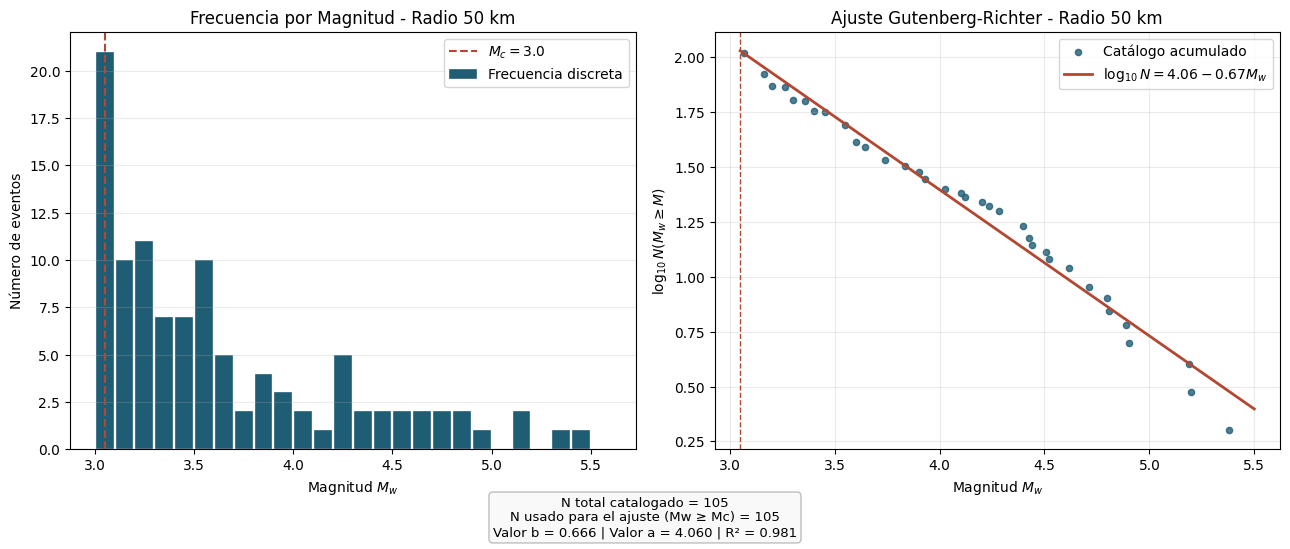

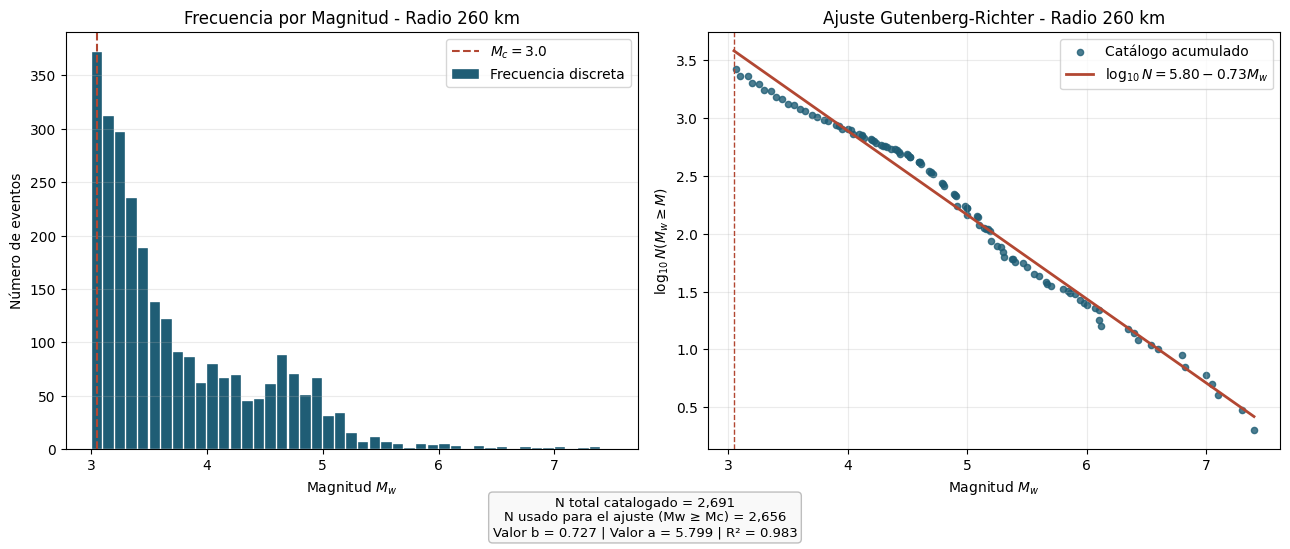


--- RESUMEN DE PARÁMETROS OBTENIDOS ---
Radio               Archivo   Mc  a_value  b_value    R2  N_total  N_ajuste_Mc
 50KM  Sismos_50_mw_def.csv 3.05    4.060    0.666 0.981      105          105
260KM Sismos_260_mw_def.csv 3.05    5.799    0.727 0.983     2691         2656

✅ Resultados exportados a: C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados\resumen_gutenberg_richter_onlymw.csv


In [39]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------- CONFIGURACIÓN DE RUTAS -----------------
# Ajusta la ruta base según tu entorno local
DIRECTORIO_DEPURADOS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos depurados"
DIR_FIGURAS = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras"

os.makedirs(DIR_FIGURAS, exist_ok=True)

ARCHIVOS = {
    "50KM": "Sismos_50_mw_def.csv",
    "260KM": "Sismos_260_mw_def.csv"
}

ANCHO_BIN = 0.1

def cargar_magnitudes(nombre_archivo):
    """Carga la columna escala_mw del archivo CSV depurado."""
    ruta = os.path.join(DIRECTORIO_DEPURADOS, nombre_archivo)
    df = pd.read_csv(ruta)
    
    # Manejar el nombre de la columna de magnitud (escala_mw)
    col_mw = "escala_mw" if "escala_mw" in df.columns else "magnitude_mw"
    magnitudes = pd.to_numeric(df[col_mw], errors="coerce").dropna()
    return df, magnitudes.to_numpy()

def ajustar_gr(magnitudes):
    """Calcula Mc y ajusta los parámetros a y b de Gutenberg-Richter."""
    minimo = np.floor(magnitudes.min() / ANCHO_BIN) * ANCHO_BIN
    maximo = np.ceil(magnitudes.max() / ANCHO_BIN) * ANCHO_BIN + ANCHO_BIN
    bordes = np.arange(minimo, maximo + ANCHO_BIN / 2, ANCHO_BIN)
    
    frecuencias, _ = np.histogram(magnitudes, bins=bordes)
    centros = bordes[:-1] + ANCHO_BIN / 2
    
    # Magnitud de completitud Mc (Máxima curvatura)
    indice_mc = int(np.argmax(frecuencias))
    mc = float(centros[indice_mc])
    umbral = mc

    valores = np.sort(magnitudes[magnitudes >= umbral])
    magnitudes_unicas = np.unique(valores)
    acumuladas = np.array([(valores >= valor).sum() for valor in magnitudes_unicas])
    
    mascara = acumuladas >= 2
    x = magnitudes_unicas[mascara]
    y = np.log10(acumuladas[mascara])
    
    # Ajuste lineal log10(N) = a - b*Mw
    pendiente, intercepto = np.polyfit(x, y, 1)
    prediccion = intercepto + pendiente * x
    
    ss_res = np.sum((y - prediccion) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
    
    b = -pendiente
    a = intercepto

    return {
        "mc": mc,
        "umbral": umbral,
        "a": a,
        "b": b,
        "r2": r2,
        "n_total": len(magnitudes),
        "n_ajuste": len(valores),
        "centros": centros,
        "frecuencias": frecuencias,
        "x": x,
        "acumuladas": acumuladas[mascara],
        "max_mag": magnitudes.max()
    }

def graficar_recurrencia(radio, nombre_archivo):
    """Genera la figura con el histograma de frecuencias y el ajuste GR."""
    df, magnitudes = cargar_magnitudes(nombre_archivo)
    ajuste = ajustar_gr(magnitudes)
    
    figura, ejes = plt.subplots(1, 2, figsize=(13, 5.5))
    color = "#1f5d75"
    color_ajuste = "#b24732"

    # 1. Histograma Frecuencia no acumulada por magnitud
    ejes[0].bar(
        ajuste["centros"],
        ajuste["frecuencias"],
        width=ANCHO_BIN * 0.9,
        color=color,
        edgecolor="white",
        linewidth=0.25,
        label="Frecuencia discreta"
    )
    ejes[0].axvline(
        ajuste["mc"],
        color=color_ajuste,
        linestyle="--",
        linewidth=1.5,
        label=fr"$M_c={ajuste['mc']:.1f}$"
    )
    ejes[0].set_title(f"Frecuencia por Magnitud - Radio {radio.replace('KM', ' km')}")
    ejes[0].set_xlabel(r"Magnitud $M_w$")
    ejes[0].set_ylabel("Número de eventos")
    ejes[0].legend(frameon=True)
    ejes[0].grid(axis="y", alpha=0.25)

    # 2. Ajuste Gutenberg-Richter (Frecuencia Acumulada)
    ejes[1].scatter(
        ajuste["x"],
        np.log10(ajuste["acumuladas"]),
        s=20,
        color=color,
        alpha=0.8,
        label="Catálogo acumulado"
    )
    
    limite = np.array([ajuste["umbral"], ajuste["max_mag"]])
    ejes[1].plot(
        limite,
        ajuste["a"] - ajuste["b"] * limite,
        color=color_ajuste,
        linewidth=2,
        label=fr"$\log_{{10}}N = {ajuste['a']:.2f} - {ajuste['b']:.2f} M_w$"
    )
    ejes[1].axvline(ajuste["mc"], color=color_ajuste, linestyle="--", linewidth=1)
    ejes[1].set_title(f"Ajuste Gutenberg-Richter - Radio {radio.replace('KM', ' km')}")
    ejes[1].set_xlabel(r"Magnitud $M_w$")
    ejes[1].set_ylabel(r"$\log_{10} N(M_w \geq M)$")
    ejes[1].legend(frameon=True, loc="upper right")
    ejes[1].grid(alpha=0.25)

    # Anotación explicativa al pie del gráfico
    texto = (
        f"N total catalogado = {ajuste['n_total']:,}\n"
        f"N usado para el ajuste (Mw ≥ Mc) = {ajuste['n_ajuste']:,}\n"
        f"Valor b = {ajuste['b']:.3f} | Valor a = {ajuste['a']:.3f} | R² = {ajuste['r2']:.3f}"
    )
    figura.text(0.5, 0.01, texto, ha="center", va="bottom", fontsize=9.5, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="whitesmoke", edgecolor="gray", alpha=0.5))
    
    figura.tight_layout(rect=(0, 0.06, 1, 1))
    
    salida = os.path.join(DIR_FIGURAS, f"gutenberg_richter_{radio.lower()}_onlymw.png")
    figura.savefig(salida, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figura)
    
    return ajuste

# ==============================================================================
# EJECUCIÓN DEL ANÁLISIS
# ==============================================================================

resultados = []

print("\n" + "="*70)
print("INICIANDO ANÁLISIS DE RECURRENCIA (GUTENBERG-RICHTER)")
print("="*70)

for radio, archivo in ARCHIVOS.items():
    try:
        ajuste = graficar_recurrencia(radio, archivo)
        resultados.append({
            "Radio": radio,
            "Archivo": archivo,
            "Mc": ajuste["mc"],
            "a_value": round(ajuste["a"], 3),
            "b_value": round(ajuste["b"], 3),
            "R2": round(ajuste["r2"], 3),
            "N_total": ajuste["n_total"],
            "N_ajuste_Mc": ajuste["n_ajuste"]
        })
    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo: {archivo}")
    except Exception as e:
        print(f"[ERROR] Error procesando {radio}: {e}")

# Guardar la tabla resumen de resultados
if resultados:
    df_resumen = pd.DataFrame(resultados)
    ruta_resumen = os.path.join(DIRECTORIO_DEPURADOS, "resumen_gutenberg_richter_onlymw.csv")
    df_resumen.to_csv(ruta_resumen, index=False, encoding="utf-8-sig")
    
    print("\n--- RESUMEN DE PARÁMETROS OBTENIDOS ---")
    print(df_resumen.to_string(index=False))
    print(f"\n✅ Resultados exportados a: {ruta_resumen}")

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. CONFIGURACIÓN DE RUTAS DE ENTRADA Y SALIDA
# ---------------------------------------------------------
INPUT_CSV = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\recursos\Qgis\datos\Sismos_260_clasificados_20261004_192107.csv"
OUTPUT_DIR = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------
# 2. CARGA Y PROCESAMIENTO DE DATOS
# ---------------------------------------------------------
# Carga con codificación latin1
df = pd.read_csv(INPUT_CSV, encoding='latin1')

# Convertir la columna 'Mw' directamente a flotante
df['mag'] = pd.to_numeric(df['Mw'], errors='coerce')

# Extraer el año manejando formatos de hora mixtos (milisegundos/zonas horarias mixtas)
df['anio'] = pd.to_datetime(df['hora'], format='mixed', errors='coerce').dt.year

# Depurar registros sin año o magnitud
df_clean = df.dropna(subset=['anio', 'mag']).copy()
df_clean['anio'] = df_clean['anio'].astype(int)
df_clean = df_clean.sort_values('anio')

min_year = int(df_clean['anio'].min())
max_year = int(df_clean['anio'].max())
total_years = max_year - min_year + 1

print(f"Registros procesados correctamente: {len(df_clean)} de {len(df)}")
print(f"Rango de años evaluado: {min_year} - {max_year} ({total_years} años)")

# ---------------------------------------------------------
# 3. RANGOS DE MAGNITUD Y VENTANAS TEMPORALES
# ---------------------------------------------------------
mag_bins = [
    (3.0, 4.0),
    (4.0, 5.0),
    (5.0, 6.0),
    (6.0, 7.0),
    (7.0, 10.0)
]

T_values = np.arange(1, total_years + 1)

# ---------------------------------------------------------
# 4. GRÁFICO 1: MÉTODO DE STEPP (1972)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for m_min, m_max in mag_bins:
    if m_max == 10.0:
        label_str = f"M ≥ {m_min:.1f}"
        sub_df = df_clean[df_clean['mag'] >= m_min]
    else:
        label_str = f"{m_min:.1f} ≤ M < {m_max:.1f}"
        sub_df = df_clean[(df_clean['mag'] >= m_min) & (df_clean['mag'] < m_max)]
    
    if len(sub_df) == 0:
        continue

    sigmas = []
    Ts = []
    
    for T in T_values:
        start_year = max_year - T + 1
        count = len(sub_df[sub_df['anio'] >= start_year])
        
        if count > 0:
            lambda_val = count / T
            sigma = np.sqrt(lambda_val / T)
            sigmas.append(sigma)
            Ts.append(T)

    if Ts:
        plt.loglog(Ts, sigmas, 'o-', label=f"{label_str} (N={len(sub_df)})", markersize=4)

# Línea de tendencia teórica con pendiente 1/sqrt(T)
T_ref = np.array([1, total_years])
sigma_ref = 0.1 / np.sqrt(T_ref)
plt.loglog(T_ref, sigma_ref, 'k--', label='Pendiente teórica 1/√T')

plt.xlabel('Ventana de tiempo T (años hacia atrás desde el año más reciente)')
plt.ylabel('Desviación estándar de la tasa anual σ_λ')
plt.title('Análisis de Completitud Temporal - Método de Stepp (1972)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()

stepp_path = os.path.join(OUTPUT_DIR, "stepp_completitud.png")
plt.savefig(stepp_path, dpi=300)
plt.close()

# ---------------------------------------------------------
# 5. GRÁFICO 2: EVENTOS ACUMULADOS (CUSUM)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for m_min, m_max in mag_bins:
    if m_max == 10.0:
        label_str = f"M ≥ {m_min:.1f}"
        sub_df = df_clean[df_clean['mag'] >= m_min]
    else:
        label_str = f"{m_min:.1f} ≤ M < {m_max:.1f}"
        sub_df = df_clean[(df_clean['mag'] >= m_min) & (df_clean['mag'] < m_max)]
    
    if len(sub_df) == 0:
        continue
    
    counts_by_year = sub_df.groupby('anio').size().reindex(range(min_year, max_year + 1), fill_value=0)
    cumsum_events = counts_by_year.cumsum()
    
    plt.plot(cumsum_events.index, cumsum_events.values, label=f"{label_str} (N={len(sub_df)})", linewidth=1.8)

plt.xlabel('Año')
plt.ylabel('Número acumulado de sismos')
plt.title('Acumulado Histórico de Eventos por Rango de Magnitud (Mw)')
plt.grid(True, ls="--", alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()

cusum_path = os.path.join(OUTPUT_DIR, "acumulado_eventos.png")
plt.savefig(cusum_path, dpi=300)
plt.close()

print("\nProcesamiento completado. Imágenes guardadas en:")
print(f" - {stepp_path}")
print(f" - {cusum_path}")

Registros procesados correctamente: 2691 de 2691
Rango de años evaluado: 1917 - 2026 (110 años)

Procesamiento completado. Imágenes guardadas en:
 - C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras\stepp_completitud.png
 - C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras\acumulado_eventos.png


In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

# -----------------------------------------------------------------------------
# 1. CONFIGURACIÓN DE RUTAS Y ESTILO
# -----------------------------------------------------------------------------
RUTA_FUENTE = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\recursos\Qgis\datos\Sismos_260_clasificados_20261004_192107.csv"
CARPETA_DESTINO = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos estadistica"

os.makedirs(CARPETA_DESTINO, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.titlesize": 14,
    }
)

PALETA_FUENTES = {
    "Cortical": "#e74c3c",
    "Subducción interplaca": "#3498db",
    "Subducción intraplaca": "#2ecc71",
}

# -----------------------------------------------------------------------------
# 2. CARGA Y PREPROCESAMIENTO DE DATOS
# -----------------------------------------------------------------------------
df = pd.read_csv(RUTA_FUENTE, encoding="latin1")

# Conversión y extracción temporal
df["datetime"] = pd.to_datetime(df["hora"], format="mixed", errors="coerce")
df["anio"] = df["datetime"].dt.year.astype(int)
df["mes"] = df["datetime"].dt.month.astype(int)
df["nombre_mes"] = df["datetime"].dt.strftime("%B")
df["dia_semana"] = df["datetime"].dt.day_name()
df["hora_dia"] = df["datetime"].dt.hour.astype(int)

# Formateo numérico
df["Mw"] = pd.to_numeric(df["Mw"], errors="coerce")
df["Z"] = pd.to_numeric(df["Z"], errors="coerce")
df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")


# Clasificación de profundidad sismogénica
def clasificar_profundidad(z):
    if z <= 30:
        return "Superficial (Z ≤ 30 km)"
    elif z <= 120:
        return "Intermedio (30 < Z ≤ 120 km)"
    else:
        return "Profundo (Z > 120 km)"


df["tipo_profundidad"] = df["Z"].apply(clasificar_profundidad)

# Estimación de Energía Sísmica Liberada (Joules): log10(E) = 1.5 * Mw + 4.8
df["energia_J"] = 10 ** (1.5 * df["Mw"] + 4.8)

# -----------------------------------------------------------------------------
# 3. TABLA 1: ESTADÍSTICA DESCRIPTIVA GENERAL
# -----------------------------------------------------------------------------
cols_num = ["Mw", "Z", "latitud", "longitud", "energia_J"]
desc_stats = df[cols_num].describe().T
desc_stats["mediana"] = df[cols_num].median()
desc_stats["rango_intercuartil_IQR"] = df[cols_num].quantile(0.75) - df[
    cols_num
].quantile(0.25)
desc_stats["asimetria"] = df[cols_num].skew()
desc_stats["curtosis"] = df[cols_num].kurt()

desc_stats.to_csv(
    os.path.join(CARPETA_DESTINO, "1_estadistica_descriptiva_general.csv")
)


# -----------------------------------------------------------------------------
# 4. TABLA 2: RESUMEN Y PARÁMETROS B-VALUE POR TIPO DE FUENTE
# -----------------------------------------------------------------------------
def estimar_gutenberg_richter(mags, mc=3.0):
    m_filt = mags[mags >= mc]
    n = len(m_filt)
    if n < 5:
        return np.nan, np.nan, np.nan, n
    mean_m = m_filt.mean()
    b = (1.0 / (mean_m - (mc - 0.05))) * np.log10(np.e)
    std_err = b / np.sqrt(n)
    a = np.log10(n) + b * mc
    return b, std_err, a, n


resumen_fuentes = []
for fuente, grp in df.groupby("fuente"):
    b_val, err_val, a_val, n_val = estimar_gutenberg_richter(grp["Mw"], mc=3.0)
    resumen_fuentes.append(
        {
            "Fuente Sismogénica": fuente,
            "N° Sismos": len(grp),
            "Porcentaje (%)": round(len(grp) / len(df) * 100, 2),
            "Mw Promedio": round(grp["Mw"].mean(), 2),
            "Mw Máxima": round(grp["Mw"].max(), 2),
            "Profundidad Promedio (km)": round(grp["Z"].mean(), 1),
            "Profundidad Máxima (km)": round(grp["Z"].max(), 1),
            "Energía Total (J)": f"{grp['energia_J'].sum():.3e}",
            "Valor b (G-R)": round(b_val, 3) if not np.isnan(b_val) else None,
            "Error std b": round(err_val, 3) if not np.isnan(err_val) else None,
            "Valor a (G-R)": round(a_val, 3) if not np.isnan(a_val) else None,
        }
    )

df_resumen_fuentes = pd.DataFrame(resumen_fuentes)
df_resumen_fuentes.to_csv(
    os.path.join(CARPETA_DESTINO, "2_resumen_por_fuente.csv"), index=False
)

# -----------------------------------------------------------------------------
# 5. TABLA 3: RECURRENCIA Y PERIODOS DE RETORNO (Tr)
# -----------------------------------------------------------------------------
anio_min, anio_max = int(df["anio"].min()), int(df["anio"].max())
periodo_evaluacion = anio_max - anio_min + 1

umbrales_mw = [3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
datos_recurrencia = []

lista_fuentes = ["CATÁLOGO TOTAL"] + list(df["fuente"].unique())

for fte in lista_fuentes:
    sub_df = df if fte == "CATÁLOGO TOTAL" else df[df["fuente"] == fte]
    for m0 in umbrales_mw:
        n_eventos = (sub_df["Mw"] >= m0).sum()
        tasa_anual = n_eventos / periodo_evaluacion
        tr = 1.0 / tasa_anual if tasa_anual > 0 else np.nan
        prob_50 = (
            (1.0 - np.exp(-tasa_anual * 50)) * 100 if tasa_anual > 0 else 0.0
        )
        prob_100 = (
            (1.0 - np.exp(-tasa_anual * 100)) * 100 if tasa_anual > 0 else 0.0
        )

        datos_recurrencia.append(
            {
                "Fuente / Catálogo": fte,
                "Magnitud Umbral (Mw ≥ M0)": m0,
                "N° Eventos Cumplidos": n_eventos,
                "Periodo Evaluación (años)": periodo_evaluacion,
                "Tasa Anual λ (eventos/año)": round(tasa_anual, 4),
                "Periodo de Retorno Tr (años)": (
                    round(tr, 2) if not np.isnan(tr) else "N/A"
                ),
                "Prob. Excedencia a 50 años (%)": round(prob_50, 2),
                "Prob. Excedencia a 100 años (%)": round(prob_100, 2),
            }
        )

df_recurrencia = pd.DataFrame(datos_recurrencia)
df_recurrencia.to_csv(
    os.path.join(
        CARPETA_DESTINO, "3_analisis_recurrencia_y_periodos_retorno.csv"
    ),
    index=False,
)

# -----------------------------------------------------------------------------
# 6. TABLA 4: ANÁLISIS ANUAL COMPLETO
# -----------------------------------------------------------------------------
df_anual = (
    df.groupby("anio")
    .agg(
        total_sismos=("Mw", "count"),
        mw_maxima=("Mw", "max"),
        mw_promedio=("Mw", "mean"),
        profundidad_promedio_km=("Z", "mean"),
        energia_total_J=("energia_J", "sum"),
    )
    .reset_index()
)

pivot_fuente_anual = df.pivot_table(
    index="anio", columns="fuente", values="Mw", aggfunc="count", fill_value=0
)
df_anual = df_anual.merge(pivot_fuente_anual, on="anio", how="left")
df_anual.to_csv(
    os.path.join(CARPETA_DESTINO, "4_analisis_anual.csv"), index=False
)

# -----------------------------------------------------------------------------
# 7. TABLA 5: ANÁLISIS MENSUAL Y HORARIO
# -----------------------------------------------------------------------------
df_mensual = (
    df.groupby("mes")
    .agg(
        total_sismos=("Mw", "count"),
        mw_maxima=("Mw", "max"),
        mw_promedio=("Mw", "mean"),
    )
    .reset_index()
)
df_mensual["porcentaje (%)"] = round(
    df_mensual["total_sismos"] / len(df) * 100, 2
)

df_horario = (
    df.groupby("hora_dia")
    .agg(total_sismos=("Mw", "count"), mw_maxima=("Mw", "max"))
    .reset_index()
)
df_horario["porcentaje (%)"] = round(
    df_horario["total_sismos"] / len(df) * 100, 2
)

df_mensual.to_csv(
    os.path.join(CARPETA_DESTINO, "5_analisis_mensual.csv"), index=False
)
df_horario.to_csv(
    os.path.join(CARPETA_DESTINO, "5_analisis_horario.csv"), index=False
)

# -----------------------------------------------------------------------------
# 8. TABLA 6: TOP 20 SISMOS MÁS SEVEROS
# -----------------------------------------------------------------------------
top20_sismos = df.sort_values(by="Mw", ascending=False).head(20)[
    [
        "id",
        "hora",
        "anio",
        "latitud",
        "longitud",
        "Z",
        "Mw",
        "fuente",
        "agencia",
        "lugar",
        "energia_J",
    ]
]
top20_sismos.to_csv(
    os.path.join(CARPETA_DESTINO, "6_sismos_mas_severos_top20.csv"), index=False
)

# -----------------------------------------------------------------------------
# 9. GENERACIÓN Y EXPORTACIÓN DE FIGURAS GRÁFICAS (300 DPI)
# -----------------------------------------------------------------------------

# Fig 01: Distribución General Magnitud y Profundidad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["Mw"], kde=True, color="teal", ax=axes[0, 0], bins=30)
axes[0, 0].set_title("Distribución de Magnitud (Mw)", fontweight="bold")
axes[0, 0].set_xlabel("Magnitud Mw")
axes[0, 0].set_ylabel("Frecuencia")

sns.boxplot(x=df["Mw"], color="teal", ax=axes[0, 1])
axes[0, 1].set_title("Boxplot de Magnitud (Mw)", fontweight="bold")
axes[0, 1].set_xlabel("Magnitud Mw")

sns.histplot(df["Z"], kde=True, color="saddlebrown", ax=axes[1, 0], bins=30)
axes[1, 0].set_title("Distribución de Profundidad (km)", fontweight="bold")
axes[1, 0].set_xlabel("Profundidad Z (km)")
axes[1, 0].set_ylabel("Frecuencia")

sns.boxplot(x=df["Z"], color="saddlebrown", ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de Profundidad Z (km)", fontweight="bold")
axes[1, 1].set_xlabel("Profundidad Z (km)")

plt.tight_layout()
plt.savefig(
    os.path.join(
        CARPETA_DESTINO,
        "fig_01_distribucion_general_magnitud_profundidad.png",
    ),
    dpi=300,
)
plt.close()

# Fig 02: Conteo anual de sismos
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    df_anual["anio"],
    df_anual["total_sismos"],
    color="#2c3e50",
    alpha=0.7,
)
ax.set_xlabel("Año", fontweight="bold")
ax.set_ylabel("Cantidad de sismos", fontweight="bold")
ax.set_title("Conteo anual de sismos", fontweight="bold", fontsize=13)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(
    os.path.join(CARPETA_DESTINO, "fig_02_sismicidad_anual_y_energia.png"),
    dpi=300,
)
plt.close()

# Fig 03: Patrones Temporales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

meses_labels = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]
axes[0].bar(meses_labels, df_mensual["total_sismos"], color="#34495e")
axes[0].set_title("Distribución Mensual Acumulada", fontweight="bold")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("N° Sismos")

axes[1].plot(
    df_horario["hora_dia"],
    df_horario["total_sismos"],
    marker="o",
    color="#e67e22",
    linewidth=2,
)
axes[1].set_title("Distribución Horaria (Ciclo Diario UTC)", fontweight="bold")
axes[1].set_xlabel("Hora del Día")
axes[1].set_ylabel("N° Sismos")
axes[1].set_xticks(range(0, 24, 2))

dias_orden = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
dias_es = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
conteos_semana = df["dia_semana"].value_counts().reindex(dias_orden)
axes[2].bar(dias_es, conteos_semana.values, color="#27ae60")
axes[2].set_title("Distribución por Día de la Semana", fontweight="bold")
axes[2].set_xlabel("Día de la Semana")
axes[2].set_ylabel("N° Sismos")

plt.tight_layout()
plt.savefig(
    os.path.join(
        CARPETA_DESTINO, "fig_03_patrones_temporales_mes_hora_semana.png"
    ),
    dpi=300,
)
plt.close()

# Fig 04: Análisis por Fuente Sismogénica (DIAGRAMAS DE VIOLÍN)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

orden_fuentes = [f for f in PALETA_FUENTES.keys() if f in df["fuente"].unique()]

# Subplot 01: Magnitud Mw por Fuente
sns.violinplot(
    data=df,
    x="fuente",
    y="Mw",
    palette=PALETA_FUENTES,
    ax=axes[0],
    hue="fuente",
    order=orden_fuentes,
    inner=None,
    cut=0,
    linewidth=1.2,
)
if axes[0].get_legend():
    axes[0].get_legend().remove()

for i, fte in enumerate(orden_fuentes):
    sub = df[df["fuente"] == fte]["Mw"]
    if len(sub) > 0:
        media = sub.mean()
        mediana = sub.median()
        max_val = sub.max()

        axes[0].hlines(
            y=media,
            xmin=i - 0.22,
            xmax=i + 0.22,
            colors="black",
            linestyles="-",
            lw=2.0,
            zorder=5,
        )
        axes[0].plot(
            i, media, marker="o", color="black", markersize=6, zorder=6
        )

        axes[0].hlines(
            y=mediana,
            xmin=i - 0.22,
            xmax=i + 0.22,
            colors="#f39c12",
            linestyles="--",
            lw=2.0,
            zorder=5,
        )
        axes[0].plot(
            i,
            mediana,
            marker="D",
            color="#f39c12",
            markeredgecolor="black",
            markersize=6,
            zorder=6,
        )

        axes[0].annotate(
            f"Media (μ): {media:.2f}\nMediana ($Q_2$): {mediana:.2f}",
            xy=(i, max_val),
            xytext=(i, max_val + 0.35),
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#bdc3c7",
                alpha=0.95,
            ),
        )

axes[0].set_title(
    "Distribución de Magnitud ($M_w$) por Fuente",
    fontweight="bold",
    pad=25,
)
axes[0].set_xlabel("Fuente Sismogénica", fontweight="bold")
axes[0].set_ylabel("Magnitud $M_w$", fontweight="bold")
axes[0].set_ylim(df["Mw"].min() - 0.5, df["Mw"].max() + 1.2)

# Subplot 02: Profundidad Z por Fuente
sns.violinplot(
    data=df,
    x="fuente",
    y="Z",
    palette=PALETA_FUENTES,
    ax=axes[1],
    hue="fuente",
    order=orden_fuentes,
    inner=None,
    cut=0,
    linewidth=1.2,
)
if axes[1].get_legend():
    axes[1].get_legend().remove()

for i, fte in enumerate(orden_fuentes):
    sub = df[df["fuente"] == fte]["Z"]
    if len(sub) > 0:
        media = sub.mean()
        mediana = sub.median()
        max_val = sub.max()

        axes[1].hlines(
            y=media,
            xmin=i - 0.22,
            xmax=i + 0.22,
            colors="black",
            linestyles="-",
            lw=2.0,
            zorder=5,
        )
        axes[1].plot(
            i, media, marker="o", color="black", markersize=6, zorder=6
        )

        axes[1].hlines(
            y=mediana,
            xmin=i - 0.22,
            xmax=i + 0.22,
            colors="#f39c12",
            linestyles="--",
            lw=2.0,
            zorder=5,
        )
        axes[1].plot(
            i,
            mediana,
            marker="D",
            color="#f39c12",
            markeredgecolor="black",
            markersize=6,
            zorder=6,
        )

        axes[1].annotate(
            f"Media (μ): {media:.1f} km\nMediana ($Q_2$): {mediana:.1f} km",
            xy=(i, max_val),
            xytext=(i, max_val + (df["Z"].max() * 0.05)),
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#bdc3c7",
                alpha=0.95,
            ),
        )

axes[1].set_title(
    "Distribución de Profundidad ($Z$) por Fuente",
    fontweight="bold",
    pad=25,
)
axes[1].set_xlabel("Fuente Sismogénica", fontweight="bold")
axes[1].set_ylabel("Profundidad $Z$ (km)", fontweight="bold")
axes[1].set_ylim(df["Z"].min() - 10, df["Z"].max() + (df["Z"].max() * 0.22))

elementos_leyenda = [
    Line2D(
        [0],
        [0],
        color="black",
        lw=2.0,
        linestyle="-",
        marker="o",
        markersize=6,
        label="Media ($\mu$)",
    ),
    Line2D(
        [0],
        [0],
        color="#f39c12",
        lw=2.0,
        linestyle="--",
        marker="D",
        markeredgecolor="black",
        markersize=6,
        label="Mediana ($Q_2$)",
    ),
]

fig.legend(
    handles=elementos_leyenda,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(
    os.path.join(CARPETA_DESTINO, "fig_04_analisis_por_fuente_sismica.png"),
    dpi=300,
)
plt.close()

# -----------------------------------------------------------------------------
# Fig 05: Ley de Gutenberg-Richter (Corregido TeX con r"..." y \geq)
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 7))

# Catálogo Total
m_sorted = np.sort(df["Mw"].dropna())
m_unique = np.unique(m_sorted)
cum_counts = [np.sum(m_sorted >= m) for m in m_unique]

plt.semilogy(
    m_unique,
    cum_counts,
    "o",
    color="black",
    alpha=0.5,
    label="Catálogo Total (Datos Observados)",
)

b_tot, err_tot, a_tot, N_tot = estimar_gutenberg_richter(df["Mw"], mc=3.0)
m_fit = np.linspace(3.0, df["Mw"].max(), 50)
n_fit = 10 ** (a_tot - b_tot * m_fit)
plt.semilogy(
    m_fit,
    n_fit,
    "k--",
    linewidth=2,
    label=f"Ajuste Total: b={b_tot:.2f} (a={a_tot:.2f})",
)

# Fuentes Sismogénicas Individuales
for i, (fuente, grp) in enumerate(df.groupby("fuente")):
    m_s = np.sort(grp["Mw"].dropna())
    m_u = np.unique(m_s)
    c_s = [np.sum(m_s >= m) for m in m_u]

    b_f, err_f, a_f, _ = estimar_gutenberg_richter(grp["Mw"], mc=3.0)
    color_fte = PALETA_FUENTES.get(fuente, f"C{i}")

    # Puntos observados
    plt.semilogy(
        m_u,
        c_s,
        ".",
        color=color_fte,
        markersize=7,
        label=f"{fuente}: b={b_f:.2f} (a={a_f:.2f})",
    )

    # Línea de ajuste teórico por fuente
    if not np.isnan(b_f) and not np.isnan(a_f):
        m_fit_fte = np.linspace(3.0, grp["Mw"].max(), 30)
        n_fit_fte = 10 ** (a_f - b_f * m_fit_fte)
        plt.semilogy(
            m_fit_fte,
            n_fit_fte,
            ":",
            color=color_fte,
            linewidth=1.5,
            alpha=0.8,
        )

plt.title(
    r"Relación Gutenberg-Richter: $\log_{10} N(M \geq m) = a - bM$",
    fontweight="bold",
    fontsize=13,
)
plt.xlabel("Magnitud $M_w$", fontweight="bold")
plt.ylabel(
    r"Frecuencia Acumulada $N(M \geq m)$ [Escala Log]", fontweight="bold"
)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.95)
plt.tight_layout()
plt.savefig(
    os.path.join(CARPETA_DESTINO, "fig_05_ley_gutenberg_richter.png"), dpi=300
)
plt.close()

# -----------------------------------------------------------------------------
# Fig 06: Periodos de Retorno Empíricos
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

for fte in ["CATÁLOGO TOTAL"] + list(df["fuente"].unique()):
    sub = df_recurrencia[df_recurrencia["Fuente / Catálogo"] == fte]
    sub_valid = sub[sub["Periodo de Retorno Tr (años)"] != "N/A"].copy()
    sub_valid["Tr"] = sub_valid["Periodo de Retorno Tr (años)"].astype(float)

    if fte == "CATÁLOGO TOTAL":
        plt.plot(
            sub_valid["Magnitud Umbral (Mw ≥ M0)"],
            sub_valid["Tr"],
            "o-",
            linewidth=2.5,
            color="black",
            label=fte,
        )
    else:
        color_fte = PALETA_FUENTES.get(fte, None)
        plt.plot(
            sub_valid["Magnitud Umbral (Mw ≥ M0)"],
            sub_valid["Tr"],
            "s--",
            linewidth=1.8,
            color=color_fte,
            label=fte,
        )

plt.yscale("log")
plt.title(
    r"Curvas de Periodos de Retorno $T_r(M_w)$ Empíricos",
    fontweight="bold",
    fontsize=13,
)
plt.xlabel("Magnitud Umbral $M_w$", fontweight="bold")
plt.ylabel("Periodo de Retorno $T_r$ (Años) [Escala Log]", fontweight="bold")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.95)
plt.tight_layout()
plt.savefig(
    os.path.join(CARPETA_DESTINO, "fig_06_periodos_de_retorno.png"), dpi=300
)
plt.close()

# -----------------------------------------------------------------------------
# Fig 07: Distribución Espacial Epicentral
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 10))
sns.scatterplot(
    data=df,
    x="longitud",
    y="latitud",
    hue="fuente",
    size="Mw",
    sizes=(20, 250),
    palette=PALETA_FUENTES,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3,
)
plt.title(
    "Distribución Espacial de Sismos por Fuente y Magnitud",
    fontweight="bold",
    fontsize=13,
)
plt.xlabel("Longitud (°)", fontweight="bold")
plt.ylabel("Latitud (°)", fontweight="bold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(
    os.path.join(CARPETA_DESTINO, "fig_07_distribucion_espacial_mapa.png"),
    dpi=300,
)
plt.close()

# -----------------------------------------------------------------------------
# Fig 08: Matriz de Correlación
# -----------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
cols_corr = ["Mw", "Z", "latitud", "longitud", "energia_J", "anio", "hora_dia"]
sns.heatmap(
    df[cols_corr].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title(
    "Matriz de Correlación de Pearson entre Variables Numéricas",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    os.path.join(CARPETA_DESTINO, "fig_08_matriz_correlacion.png"), dpi=300
)
plt.close()

print(
    f"Proceso finalizado con éxito. Archivos y gráficos generados en:\n{CARPETA_DESTINO}"
)

Proceso finalizado con éxito. Archivos y gráficos generados en:
C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos estadistica
